# 06 — DistilBERT Sentiment Classification

In this notebook, we build a Transformer-based sentiment classifier
for the IMDb dataset.

Before training, we first learn how Transformer inputs work:

1. Tokenization
2. Token IDs
3. Special tokens
4. Padding
5. Truncation
6. Attention masks

Then we fine-tune DistilBERT for binary sentiment classification.

Labels:

- 0 = negative
- 1 = positive

In [14]:
%pip install transformers

Looking in indexes: https://pypi.org/simple/
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch

from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

In [16]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers


In [17]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imdb_clean_splits"
)

In [18]:
dataset = load_from_disk(
    str(DATA_PATH)
)

train_df = (
    dataset["train"]
    .to_pandas()[["text", "label"]]
    .copy()
)

validation_df = (
    dataset["validation"]
    .to_pandas()[["text", "label"]]
    .copy()
)

print(
    "Train:",
    f"{len(train_df):,}",
)

print(
    "Validation:",
    f"{len(validation_df):,}",
)

Train: 19,823
Validation: 4,956


In [19]:
MODEL_NAME = (
    "distilbert-base-uncased"
)

In [20]:
tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_NAME
    )
)

In [21]:
example_text = (
    "I did not like this movie."
)

print(
    example_text
)

I did not like this movie.


In [22]:
tokens = tokenizer.tokenize(
    example_text
)

tokens

['i', 'did', 'not', 'like', 'this', 'movie', '.']

In [23]:
token_ids = (
    tokenizer
    .convert_tokens_to_ids(
        tokens
    )
)

list(
    zip(
        tokens,
        token_ids,
    )
)

[('i', 1045),
 ('did', 2106),
 ('not', 2025),
 ('like', 2066),
 ('this', 2023),
 ('movie', 3185),
 ('.', 1012)]

In [24]:
encoded_example = tokenizer(
    example_text
)

encoded_example

{'input_ids': [101, 1045, 2106, 2025, 2066, 2023, 3185, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [25]:
tokens_with_special_tokens = (
    tokenizer
    .convert_ids_to_tokens(
        encoded_example[
            "input_ids"
        ]
    )
)

tokens_with_special_tokens

['[CLS]', 'i', 'did', 'not', 'like', 'this', 'movie', '.', '[SEP]']

In [26]:
token_table = pd.DataFrame(
    {
        "token": (
            tokens_with_special_tokens
        ),
        "input_id": (
            encoded_example[
                "input_ids"
            ]
        ),
        "attention_mask": (
            encoded_example[
                "attention_mask"
            ]
        ),
    }
)

token_table

,token,input_id,attention_mask
0,[CLS],101,1
1,i,1045,1
2,did,2106,1
3,not,2025,1
4,like,2066,1
5,this,2023,1
6,movie,3185,1
7,.,1012,1
8,[SEP],102,1


## 2. Padding and attention masks

Transformer batches must have a rectangular shape.

Because texts have different lengths, shorter sequences need padding.

The attention mask tells the model which positions contain real tokens
and which positions are only padding.

In [27]:
batch_texts = [
    "Great movie.",
    "This movie was surprisingly good and very entertaining.",
]

batch_texts

['Great movie.', 'This movie was surprisingly good and very entertaining.']

In [28]:
without_padding = tokenizer(
    batch_texts,
    padding=False,
)

without_padding

{'input_ids': [[101, 2307, 3185, 1012, 102], [101, 2023, 3185, 2001, 10889, 2204, 1998, 2200, 14036, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [29]:
for index, input_ids in enumerate(
    without_padding["input_ids"]
):
    print(
        f"Text {index}:",
        len(input_ids),
        "tokens",
    )

Text 0: 5 tokens
Text 1: 11 tokens


In [30]:
padded_batch = tokenizer(
    batch_texts,
    padding=True,
)

padded_batch

{'input_ids': [[101, 2307, 3185, 1012, 102, 0, 0, 0, 0, 0, 0], [101, 2023, 3185, 2001, 10889, 2204, 1998, 2200, 14036, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [31]:
for index, input_ids in enumerate(
    padded_batch["input_ids"]
):
    print(
        f"Text {index}:",
        len(input_ids),
        "tokens",
    )

Text 0: 11 tokens
Text 1: 11 tokens


In [32]:
for index, input_ids in enumerate(
    padded_batch["input_ids"]
):
    tokens = tokenizer.convert_ids_to_tokens(
        input_ids
    )

    print(
        f"Text {index}:"
    )

    print(tokens)

    print()

Text 0:
['[CLS]', 'great', 'movie', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Text 1:
['[CLS]', 'this', 'movie', 'was', 'surprisingly', 'good', 'and', 'very', 'entertaining', '.', '[SEP]']



In [33]:
for index in range(
    len(batch_texts)
):
    tokens = (
        tokenizer
        .convert_ids_to_tokens(
            padded_batch[
                "input_ids"
            ][index]
        )
    )

    attention_mask = (
        padded_batch[
            "attention_mask"
        ][index]
    )

    display_df = pd.DataFrame(
        {
            "token": tokens,
            "attention_mask": attention_mask,
        }
    )

    print(
        f"Text {index}:"
    )

    display(display_df)

Text 0:


,token,attention_mask
0,[CLS],1
1,great,1
2,movie,1
3,.,1
4,[SEP],1
5,[PAD],0
6,[PAD],0
7,[PAD],0
8,[PAD],0
9,[PAD],0


Text 1:


,token,attention_mask
0,[CLS],1
1,this,1
2,movie,1
3,was,1
4,surprisingly,1
5,good,1
6,and,1
7,very,1
8,entertaining,1
9,.,1


In [34]:
tensor_batch = tokenizer(
    batch_texts,
    padding=True,
    return_tensors="pt",
)

tensor_batch

{'input_ids': tensor([[  101,  2307,  3185,  1012,   102,     0,     0,     0,     0,     0,
             0],
        [  101,  2023,  3185,  2001, 10889,  2204,  1998,  2200, 14036,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [35]:
print(
    type(
        tensor_batch[
            "input_ids"
        ]
    )
)

print(
    type(
        tensor_batch[
            "attention_mask"
        ]
    )
)

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [36]:
long_text = (
    "This movie was very interesting. "
    * 200
)

print(
    "Characters:",
    len(long_text),
)

Characters: 6600


In [37]:
long_tokens = tokenizer.tokenize(
    long_text
)

print(
    "Number of tokens:",
    len(long_tokens),
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1200 > 512). Running this sequence through the model will result in indexing errors


Number of tokens: 1200


In [38]:
truncated_example = tokenizer(
    long_text,
    truncation=True,
    max_length=16,
)

print(
    "Number of input IDs:",
    len(
        truncated_example[
            "input_ids"
        ]
    ),
)

Number of input IDs: 16


In [39]:
truncated_tokens = (
    tokenizer
    .convert_ids_to_tokens(
        truncated_example[
            "input_ids"
        ]
    )
)

truncated_tokens

['[CLS]',
 'this',
 'movie',
 'was',
 'very',
 'interesting',
 '.',
 'this',
 'movie',
 'was',
 'very',
 'interesting',
 '.',
 'this',
 'movie',
 '[SEP]']

In [40]:
encoded_batch = tokenizer(
    batch_texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt",
)

encoded_batch

{'input_ids': tensor([[  101,  2307,  3185,  1012,   102,     0,     0,     0,     0,     0,
             0],
        [  101,  2023,  3185,  2001, 10889,  2204,  1998,  2200, 14036,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [41]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device,
)

Device: cuda


## 3. Load the pretrained DistilBERT classifier

We load pretrained DistilBERT weights and attach a classification
head for our two IMDb sentiment classes.

Classes:

- 0 = negative
- 1 = positive

In [42]:
id2label = {
    0: "neg",
    1: "pos",
}

label2id = {
    "neg": 0,
    "pos": 1,
}

model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label=id2label,
        label2id=label2id,
    )
)

model = model.to(
    device
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [43]:
print(
    "Number of labels:",
    model.config.num_labels,
)

print(
    "ID to label:",
    model.config.id2label,
)

print(
    "Label to ID:",
    model.config.label2id,
)

Number of labels: 2
ID to label: {0: 'neg', 1: 'pos'}
Label to ID: {'neg': 0, 'pos': 1}


In [44]:
example_batch = tokenizer(
    batch_texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt",
)

example_batch

{'input_ids': tensor([[  101,  2307,  3185,  1012,   102,     0,     0,     0,     0,     0,
             0],
        [  101,  2023,  3185,  2001, 10889,  2204,  1998,  2200, 14036,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [45]:
example_batch = {
    key: value.to(device)
    for key, value
    in example_batch.items()
}

In [46]:
model.eval()

with torch.inference_mode():
    outputs = model(
        **example_batch
    )

In [47]:
logits = outputs.logits

print(
    "Logits:"
)

print(
    logits
)

print(
    "Shape:",
    logits.shape,
)

Logits:
tensor([[0.0502, 0.0670],
        [0.0510, 0.0759]], device='cuda:0')
Shape: torch.Size([2, 2])


In [48]:
probabilities = torch.softmax(
    logits,
    dim=-1,
)

probabilities

tensor([[0.4958, 0.5042],
        [0.4938, 0.5062]], device='cuda:0')

In [49]:
probability_sums = (
    probabilities
    .sum(
        dim=1
    )
)

probability_sums

tensor([1., 1.], device='cuda:0')

In [50]:
predicted_class_ids = (
    probabilities
    .argmax(
        dim=1
    )
)

predicted_class_ids

tensor([1, 1], device='cuda:0')

In [51]:
predicted_labels = [
    model.config.id2label[
        class_id.item()
    ]
    for class_id
    in predicted_class_ids
]

predicted_labels

['pos', 'pos']

In [52]:
prediction_demo_df = pd.DataFrame(
    {
        "text": batch_texts,
        "negative_probability": (
            probabilities[
                :, 0
            ]
            .cpu()
            .numpy()
        ),
        "positive_probability": (
            probabilities[
                :, 1
            ]
            .cpu()
            .numpy()
        ),
        "prediction": (
            predicted_labels
        ),
    }
)

prediction_demo_df

,text,negative_probability,positive_probability,prediction
0,Great movie.,0.495803,0.504197,pos
1,This movie was surprisingly good and very ente...,0.493793,0.506207,pos


In [53]:
from torch.utils.data import (
    DataLoader,
    Dataset,
)

## 4. Build the Transformer training pipeline

We now create a PyTorch Dataset and DataLoader for IMDb reviews.

Each batch will contain:

- `input_ids`
- `attention_mask`
- `labels`

Texts are dynamically padded inside each batch.

In [54]:
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 8

In [58]:
class IMDbTransformerDataset(
    Dataset
):
    def __init__(
        self,
        texts,
        labels,
    ):
        self.texts = list(
            texts
        )

        self.labels = np.asarray(
            labels,
            dtype=np.int64,
        )

    def __len__(
        self,
    ):
        return len(
            self.labels
        )

    def __getitem__(
        self,
        index,
    ):
        return {
            "text": (
                self.texts[
                    index
                ]
            ),
            "label": int(
                self.labels[
                    index
                ]
            ),
        }

In [60]:
train_dataset[10]

{'text': "There seem to have been any number of films like this released during the 70's. And the fact that I cannot recollect the title to a single one of them off-hand is a measure of their impact. These are what novelists would call 'pot-boilers'. They are scarcely more than a vehicle for keeping movie-stars in the public eye.<br /><br />We have Micheal Caine, Peter Ustinov, Omar Sharif, Rex Harrison and William Holden; more than enough names to get bums on cinema seats. Every taste in hero is catered for. Though one suspects that most of the audience still went away disappointed.<br /><br />Their talents are simply thrown away, and I wonder that stars with so much money and such reputation can be yet so desperate or lacking in good sense. This sort of movie hardly adds gilding to a CV. Sometimes maybe actors should choose their director instead of the other way round.<br /><br />It was pretty obvious that it would be crap even from the outset. That ludicrously mismatched jaunty-jaz

In [61]:
train_dataset = (
    IMDbTransformerDataset(
        texts=train_df[
            "text"
        ],
        labels=train_df[
            "label"
        ],
    )
)

validation_dataset = (
    IMDbTransformerDataset(
        texts=validation_df[
            "text"
        ],
        labels=validation_df[
            "label"
        ],
    )
)

In [62]:
print(
    "Train dataset:",
    len(train_dataset),
)

print(
    "Validation dataset:",
    len(validation_dataset),
)

Train dataset: 19823
Validation dataset: 4956


In [63]:
train_dataset[0]

{'text': 'This cool Marvel superhero game pays proper tribute by staying true to the comics. Of all the Marvel superhero games that have been so lame with weak graphics and gameplay, Spiderman improves in both departments. It also features the voice of Stan Lee, the creator of Spiderman comics.<br /><br />As you\'d expect Spiderman does whatever a spider can. He does more than spin webs. In fact, he uses them as weapons and shields. When he\'s not using web in combat, he punches and kicks as well. Spidey has his hands full as he battles Venom, Rhino, Mysterio, Scorpion, and Dr. Octopus to name a few. Look for Captain America in a cameo.<br /><br />Most of the levels are challenging, but some of them require patience to beat. The only complaint about this game is that it\'s so short and can be completed in less than three hours. If you\'re a real Marvel superhero fan, this game is for you but don\'t expect long gameplay. Better luck in "Spiderman 2." My evaluation: 9 out of 10.',
 'labe

In [66]:
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 16
VALIDATION_BATCH_SIZE = 32

In [64]:
def collate_transformer_batch(
    batch,
):
    texts = [
        item["text"]
        for item in batch
    ]

    labels = [
        item["label"]
        for item in batch
    ]

    encoded_batch = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    encoded_batch[
        "labels"
    ] = torch.tensor(
        labels,
        dtype=torch.long,
    )

    return encoded_batch

In [67]:
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=(
        collate_transformer_batch
    ),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=(
        VALIDATION_BATCH_SIZE
    ),
    shuffle=False,
    collate_fn=(
        collate_transformer_batch
    ),
)

In [69]:
example_training_batch = next(
    iter(
        train_loader
    )
)

In [70]:
for key, value in (
    example_training_batch.items()
):
    print(
        key,
        value.shape,
        value.dtype,
    )

input_ids torch.Size([16, 128]) torch.int64
token_type_ids torch.Size([16, 128]) torch.int64
attention_mask torch.Size([16, 128]) torch.int64
labels torch.Size([16]) torch.int64


In [71]:
first_input_ids = (
    example_training_batch[
        "input_ids"
    ][0]
)

decoded_text = tokenizer.decode(
    first_input_ids,
    skip_special_tokens=False,
)

print(
    decoded_text
)

[CLS] so it starts with a beautiful old house in the country. you have a group of people who get asked to come to this house and ( not surprisingly ) the caretakers always lock the gates at night for no apparent reason. anywhoo, the people laugh, joke etc. this dr tells them a spooky story of this woman and some kids. they get scared, they start to feel stuff. oh no, a girl see ' s s ghost. some more talking then this huge ghost comes and etc etc. this girl finds out that this ghost killed little kids and that she must free their souls, yeah yeah [SEP]


In [72]:
print(
    tokenizer.decode(
        first_input_ids,
        skip_special_tokens=True,
    )
)

so it starts with a beautiful old house in the country. you have a group of people who get asked to come to this house and ( not surprisingly ) the caretakers always lock the gates at night for no apparent reason. anywhoo, the people laugh, joke etc. this dr tells them a spooky story of this woman and some kids. they get scared, they start to feel stuff. oh no, a girl see ' s s ghost. some more talking then this huge ghost comes and etc etc. this girl finds out that this ghost killed little kids and that she must free their souls, yeah yeah


In [73]:
first_attention_mask = (
    example_training_batch[
        "attention_mask"
    ][0]
)

print(
    "Sequence length:",
    len(
        first_attention_mask
    ),
)

print(
    "Real tokens:",
    int(
        first_attention_mask.sum()
    ),
)

Sequence length: 128
Real tokens: 128


In [74]:
example_training_batch[
    "labels"
]

tensor([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1])

In [75]:
batch_on_device = {
    key: value.to(
        device
    )
    for key, value
    in example_training_batch.items()
}

In [76]:
model.train()

outputs = model(
    **batch_on_device
)

In [77]:
print(
    "Loss:",
    outputs.loss.item(),
)

print(
    "Logits shape:",
    outputs.logits.shape,
)

Loss: 0.6857305765151978
Logits shape: torch.Size([16, 2])


In [78]:
LEARNING_RATE = 2e-5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [79]:
training_batch = next(
    iter(train_loader)
)

In [80]:
training_batch = {
    key: value.to(device)
    for key, value
    in training_batch.items()
}

In [81]:
parameter_name, parameter = next(
    model.named_parameters()
)

weight_before_training = (
    parameter
    .detach()
    .clone()
)

print(
    "Parameter:",
    parameter_name,
)

print(
    "Shape:",
    parameter.shape,
)

Parameter: distilbert.embeddings.word_embeddings.weight
Shape: torch.Size([30522, 768])


In [82]:
model.train()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [83]:
optimizer.zero_grad()

In [84]:
outputs = model(
    **training_batch
)

In [85]:
loss = outputs.loss

print(
    "Loss before update:",
    loss.item(),
)

print(
    "Logits shape:",
    outputs.logits.shape,
)

Loss before update: 0.6692916750907898
Logits shape: torch.Size([16, 2])


In [86]:
loss.backward()

In [87]:
GRADIENT_CLIP_NORM = 1.0

gradient_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=GRADIENT_CLIP_NORM,
)

print(
    "Gradient norm:",
    gradient_norm.item(),
)

Gradient norm: 1.1998111009597778


In [88]:
optimizer.step()

In [91]:
weight_after_training = (
    parameter
    .detach()
    .clone()
)

In [92]:
weights_changed = (
    not torch.equal(
        weight_before_training,
        weight_after_training,
    )
)

print(
    "Weights changed:",
    weights_changed,
)

Weights changed: True


In [93]:
maximum_weight_change = (
    weight_after_training
    - weight_before_training
).abs().max()

print(
    "Maximum weight change:",
    maximum_weight_change.item(),
)

Maximum weight change: 2.014636993408203e-05


In [94]:
model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label=id2label,
        label2id=label2id,
    )
    .to(device)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [95]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [97]:
@torch.no_grad()
def evaluate_transformer(
    model,
    data_loader,
    device,
):
    model.eval()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    for batch in data_loader:

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        outputs = model(
            **batch
        )

        loss = outputs.loss
        logits = outputs.logits

        batch_size = (
            batch["labels"]
            .size(0)
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        predictions = (
            logits
            .argmax(dim=1)
        )

        all_predictions.append(
            predictions.cpu()
        )

        all_labels.append(
            batch["labels"]
            .cpu()
        )

    predictions = (
        torch.cat(
            all_predictions
        )
        .numpy()
    )

    labels = (
        torch.cat(
            all_labels
        )
        .numpy()
    )

    average_loss = (
        total_loss
        / len(
            data_loader.dataset
        )
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
    }

In [98]:
initial_validation_results = (
    evaluate_transformer(
        model=model,
        data_loader=validation_loader,
        device=device,
    )
)

initial_validation_results

{'loss': 0.6965756253237875,
 'accuracy': 0.5022195318805488,
 'precision': 0.5022195318805488,
 'recall': 1.0,
 'f1': 0.6686366689053056}

## 5. Fine-tune DistilBERT

We now fine-tune the pretrained DistilBERT model on the IMDb
training split.

After every epoch, we evaluate the model on the validation split.

The model with the highest validation F1 is saved as the best
Transformer checkpoint.

In [99]:
NUMBER_OF_EPOCHS = 2

In [100]:
TRANSFORMER_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "distilbert_imdb"
)

TRANSFORMER_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [101]:
training_history = []

best_validation_f1 = -1.0
best_epoch = None

In [102]:
import time

In [103]:
training_start = (
    time.perf_counter()
)

for epoch in range(
    1,
    NUMBER_OF_EPOCHS + 1,
):

    print(
        f"\nEpoch {epoch}/{NUMBER_OF_EPOCHS}"
    )

    model.train()

    total_training_loss = 0.0

    epoch_start = (
        time.perf_counter()
    )

    for batch_number, batch in enumerate(
        train_loader,
        start=1,
    ):

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(
            **batch
        )

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        batch_size = (
            batch["labels"]
            .size(0)
        )

        total_training_loss += (
            loss.item()
            * batch_size
        )

        if batch_number % 200 == 0:
            print(
                f"Batch {batch_number:,} | "
                f"Loss: {loss.item():.4f}"
            )

    average_training_loss = (
        total_training_loss
        / len(train_loader.dataset)
    )

    validation_results = (
        evaluate_transformer(
            model=model,
            data_loader=validation_loader,
            device=device,
        )
    )

    epoch_seconds = (
        time.perf_counter()
        - epoch_start
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": (
            average_training_loss
        ),
        "validation_loss": (
            validation_results[
                "loss"
            ]
        ),
        "validation_accuracy": (
            validation_results[
                "accuracy"
            ]
        ),
        "validation_precision": (
            validation_results[
                "precision"
            ]
        ),
        "validation_recall": (
            validation_results[
                "recall"
            ]
        ),
        "validation_f1": (
            validation_results[
                "f1"
            ]
        ),
        "seconds": (
            epoch_seconds
        ),
    }

    training_history.append(
        epoch_record
    )

    print(
        f"Train Loss: "
        f"{average_training_loss:.4f}"
    )

    print(
        f"Validation Loss: "
        f"{validation_results['loss']:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{validation_results['accuracy']:.4f}"
    )

    print(
        f"Validation F1: "
        f"{validation_results['f1']:.4f}"
    )

    print(
        f"Epoch Time: "
        f"{epoch_seconds:.1f}s"
    )

    if (
        validation_results["f1"]
        > best_validation_f1
    ):
        best_validation_f1 = (
            validation_results[
                "f1"
            ]
        )

        best_epoch = epoch

        model.save_pretrained(
            TRANSFORMER_MODEL_DIR
        )

        tokenizer.save_pretrained(
            TRANSFORMER_MODEL_DIR
        )

        print(
            "New best model saved."
        )


Epoch 1/2
Batch 200 | Loss: 0.7143
Batch 400 | Loss: 0.4877
Batch 600 | Loss: 0.0868
Batch 800 | Loss: 0.2681
Batch 1,000 | Loss: 0.3308
Batch 1,200 | Loss: 0.3332
Train Loss: 0.3651
Validation Loss: 0.3146
Validation Accuracy: 0.8618
Validation F1: 0.8677
Epoch Time: 147.8s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best model saved.

Epoch 2/2
Batch 200 | Loss: 0.0564
Batch 400 | Loss: 0.2506
Batch 600 | Loss: 0.4152
Batch 800 | Loss: 0.1664
Batch 1,000 | Loss: 0.1596
Batch 1,200 | Loss: 0.4747
Train Loss: 0.2367
Validation Loss: 0.3311
Validation Accuracy: 0.8793
Validation F1: 0.8791
Epoch Time: 125.7s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best model saved.


In [104]:
total_training_seconds = (
    time.perf_counter()
    - training_start
)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation F1:",
    f"{best_validation_f1:.4f}",
)

print(
    "Total training time:",
    f"{total_training_seconds:.1f}s",
)

Best epoch: 2
Best validation F1: 0.8791
Total training time: 394.2s


In [105]:
training_history_df = (
    pd.DataFrame(
        training_history
    )
)

training_history_df

,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,seconds
0,1,0.365138,0.314594,0.861784,0.835565,0.902370,0.867684,147.846553
1,2,0.236672,0.331080,0.879338,0.884819,0.873443,0.879094,125.688680


## 6. Load the best saved DistilBERT model

Training may finish on an epoch that is not the best epoch.

We therefore reload the checkpoint that achieved the highest
validation F1 before performing final evaluation.

In [106]:
best_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        TRANSFORMER_MODEL_DIR
    )
    .to(device)
)

best_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        TRANSFORMER_MODEL_DIR
    )
)

best_model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [107]:
print(
    "Labels:",
    best_model.config.id2label,
)

print(
    "Number of labels:",
    best_model.config.num_labels,
)

Labels: {0: 'neg', 1: 'pos'}
Number of labels: 2


In [108]:
best_validation_results = (
    evaluate_transformer(
        model=best_model,
        data_loader=validation_loader,
        device=device,
    )
)

best_validation_results

{'loss': 0.3310797027251334,
 'accuracy': 0.8793381759483454,
 'precision': 0.8848188848188848,
 'recall': 0.8734431498593813,
 'f1': 0.879094217549535}

In [109]:
print(
    "Recorded best F1:",
    best_validation_f1,
)

print(
    "Reloaded model F1:",
    best_validation_results[
        "f1"
    ],
)

Recorded best F1: 0.879094217549535
Reloaded model F1: 0.879094217549535


In [110]:
test_df = (
    dataset["test"]
    .to_pandas()[["text", "label"]]
    .copy()
)

print(
    "Test examples:",
    f"{len(test_df):,}",
)

Test examples: 25,000


In [111]:
IMDbTransformerDataset

__main__.IMDbTransformerDataset

In [112]:
test_dataset = (
    IMDbTransformerDataset(
        texts=test_df[
            "text"
        ],
        labels=test_df[
            "label"
        ],
    )
)

print(
    "Test dataset:",
    len(test_dataset),
)

Test dataset: 25000


In [113]:
TEST_BATCH_SIZE = 32

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    collate_fn=(
        collate_transformer_batch
    ),
)

In [114]:
def collate_test_batch(
    batch,
):
    texts = [
        item["text"]
        for item in batch
    ]

    labels = [
        item["label"]
        for item in batch
    ]

    encoded_batch = (
        best_tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
    )

    encoded_batch[
        "labels"
    ] = torch.tensor(
        labels,
        dtype=torch.long,
    )

    return encoded_batch

In [115]:
test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_test_batch,
)

In [116]:
@torch.no_grad()
def evaluate_with_predictions(
    model,
    data_loader,
    device,
):
    model.eval()

    total_loss = 0.0

    all_predictions = []
    all_probabilities = []
    all_labels = []

    for batch in data_loader:

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        outputs = model(
            **batch
        )

        logits = outputs.logits
        loss = outputs.loss

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        batch_size = (
            batch["labels"]
            .size(0)
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        all_predictions.append(
            predictions.cpu()
        )

        all_probabilities.append(
            probabilities.cpu()
        )

        all_labels.append(
            batch["labels"]
            .cpu()
        )

    predictions = (
        torch.cat(
            all_predictions
        )
        .numpy()
    )

    probabilities = (
        torch.cat(
            all_probabilities
        )
        .numpy()
    )

    labels = (
        torch.cat(
            all_labels
        )
        .numpy()
    )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    return {
        "loss": average_loss,
        "predictions": predictions,
        "probabilities": probabilities,
        "labels": labels,
    }

In [117]:
test_start = (
    time.perf_counter()
)

distilbert_test_output = (
    evaluate_with_predictions(
        model=best_model,
        data_loader=test_loader,
        device=device,
    )
)

test_seconds = (
    time.perf_counter()
    - test_start
)

In [118]:
y_test = (
    distilbert_test_output[
        "labels"
    ]
)

test_predictions = (
    distilbert_test_output[
        "predictions"
    ]
)

test_probabilities = (
    distilbert_test_output[
        "probabilities"
    ]
)

In [119]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [120]:
distilbert_accuracy = (
    accuracy_score(
        y_test,
        test_predictions,
    )
)

distilbert_precision = (
    precision_score(
        y_test,
        test_predictions,
        zero_division=0,
    )
)

distilbert_recall = (
    recall_score(
        y_test,
        test_predictions,
        zero_division=0,
    )
)

distilbert_f1 = (
    f1_score(
        y_test,
        test_predictions,
        zero_division=0,
    )
)

In [121]:
print(
    f"Test Loss:      "
    f"{distilbert_test_output['loss']:.4f}"
)

print(
    f"Test Accuracy:  "
    f"{distilbert_accuracy:.4f}"
)

print(
    f"Test Precision: "
    f"{distilbert_precision:.4f}"
)

print(
    f"Test Recall:    "
    f"{distilbert_recall:.4f}"
)

print(
    f"Test F1:        "
    f"{distilbert_f1:.4f}"
)

print(
    f"Test Time:      "
    f"{test_seconds:.1f}s"
)

Test Loss:      0.3380
Test Accuracy:  0.8744
Test Precision: 0.8774
Test Recall:    0.8705
Test F1:        0.8739
Test Time:      40.8s


In [122]:
distilbert_report = (
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "neg",
            "pos",
        ],
        output_dict=True,
        zero_division=0,
    )
)

distilbert_report_df = (
    pd.DataFrame(
        distilbert_report
    )
    .transpose()
)

distilbert_report_df

,precision,recall,f1-score,support
neg,0.871488,0.87832,0.874890,12500.0000
pos,0.877358,0.87048,0.873906,12500.0000
accuracy,0.874400,0.87440,0.874400,0.8744
macro avg,0.874423,0.87440,0.874398,25000.0000
weighted avg,0.874423,0.87440,0.874398,25000.0000


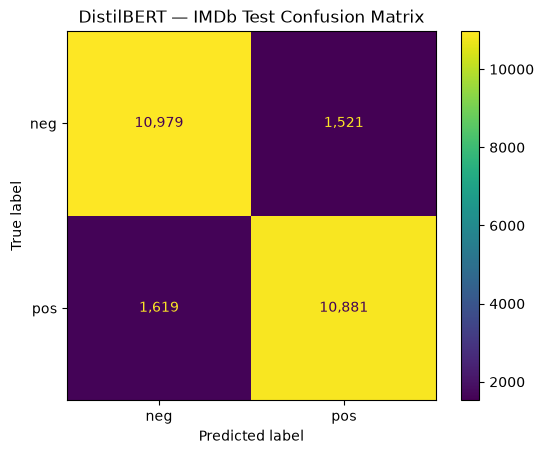

In [124]:
import matplotlib.pyplot as plt
distilbert_confusion_matrix = (
    confusion_matrix(
        y_test,
        test_predictions,
        labels=[0, 1],
    )
)

display = (
    ConfusionMatrixDisplay(
        confusion_matrix=(
            distilbert_confusion_matrix
        ),
        display_labels=[
            "neg",
            "pos",
        ],
    )
)

display.plot(
    values_format=",d"
)

plt.title(
    "DistilBERT — IMDb Test Confusion Matrix"
)

plt.show()